In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load raw datasets
soil_df = pd.read_csv("../data/processed/nepal_75_districts_soil_dataset.csv")
climate_df = pd.read_csv("../data/processed/nepal_district_climate_1979_2024.csv")
yield_df = pd.read_csv("../data/processed/crops-yield-1979-2024.csv")

In [3]:
print("--- Datasets Overview ---")
print(f"Soil Shape: {soil_df.shape}")
print(f"Climate Shape: {climate_df.shape}")
print(f"Yield Shape: {yield_df.shape}")

# Check missing values
print("\nMissing Values in Soil:", soil_df.isnull().sum().sum())
print("Missing Values in Climate:", climate_df.isnull().sum().sum())
print("Missing Values in Yield:", yield_df.isnull().sum().sum())

--- Datasets Overview ---
Soil Shape: (31, 14)
Climate Shape: (39600, 10)
Yield Shape: (3150, 20)

Missing Values in Soil: 0
Missing Values in Climate: 0
Missing Values in Yield: 0


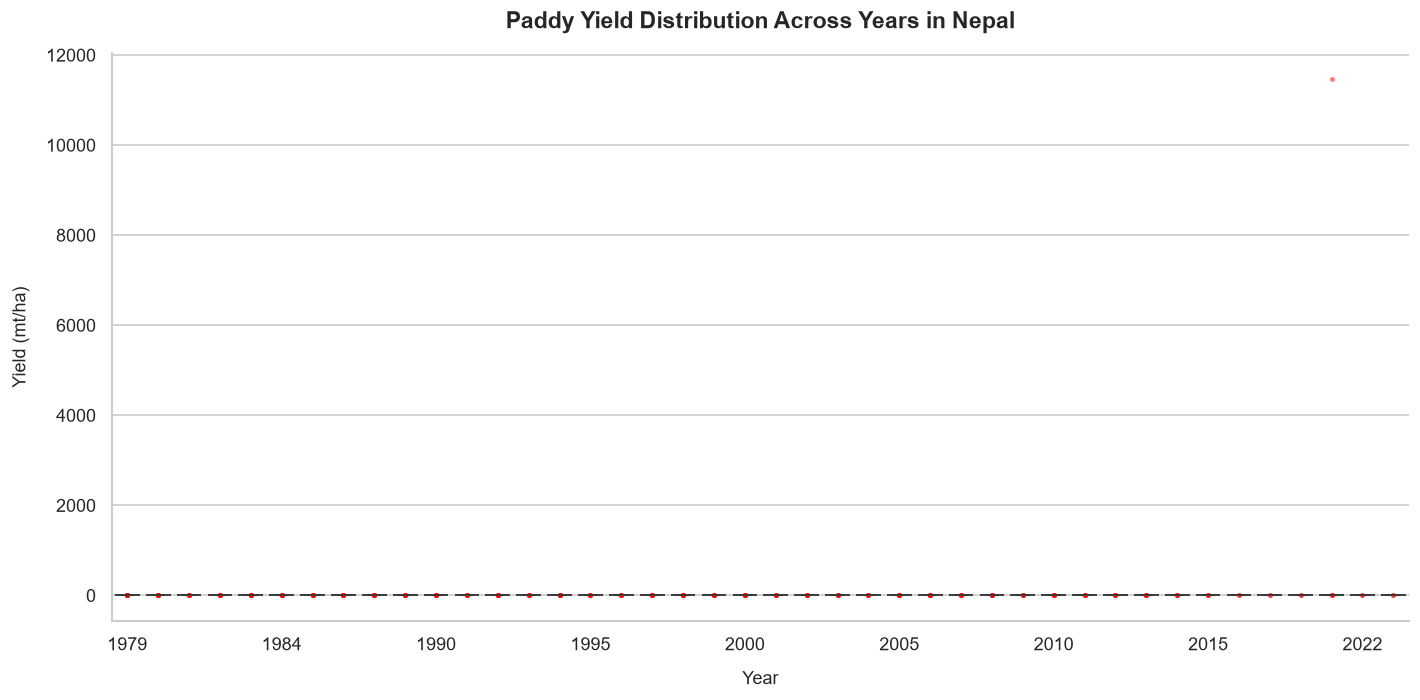

In [4]:
# Ensure 'Date' or year column is numeric
yield_df['Year'] = yield_df['Date'].astype(str).str.extract(r'(\d{4})').astype(int)

# Set clean visual style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

# Plot boxplots across continuous numeric years
sns.boxplot(
    data=yield_df,
    x='Year',
    y='PD_Y',
    ax=ax,
    color='#2b5c8f',        # Clean professional blue palette
    boxprops=dict(alpha=0.8),
    flierprops=dict(marker='o', markersize=3, markerfacecolor='red', alpha=0.5, markeredgecolor='none')
)

# Show every Nth label on the x-axis to prevent crowding
n_ticks = 5  # Show a label every 5 years
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % n_ticks != 0:
        label.set_visible(False)

# Labels & Styling
ax.set_title("Paddy Yield Distribution Across Years in Nepal", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11, labelpad=10)
ax.set_ylabel("Yield (mt/ha)", fontsize=11, labelpad=10)
ax.tick_params(axis='x', rotation=0)  # Keep labels horizontal for legibility

# Fine-tune layout & remove top/right spines
sns.despine()
plt.tight_layout()
plt.show()

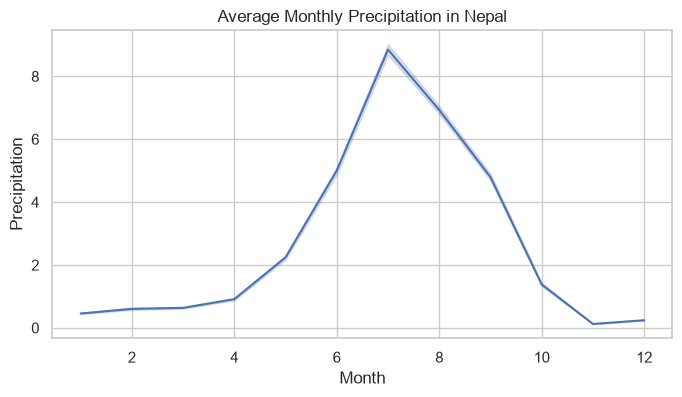

In [5]:
climate_df['DATE'] = pd.to_datetime(climate_df['DATE'])
climate_df['Month'] = climate_df['DATE'].dt.month

plt.figure(figsize=(8, 4))
sns.lineplot(data=climate_df, x='Month', y='PRECTOT', estimator='mean')
plt.title("Average Monthly Precipitation in Nepal")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

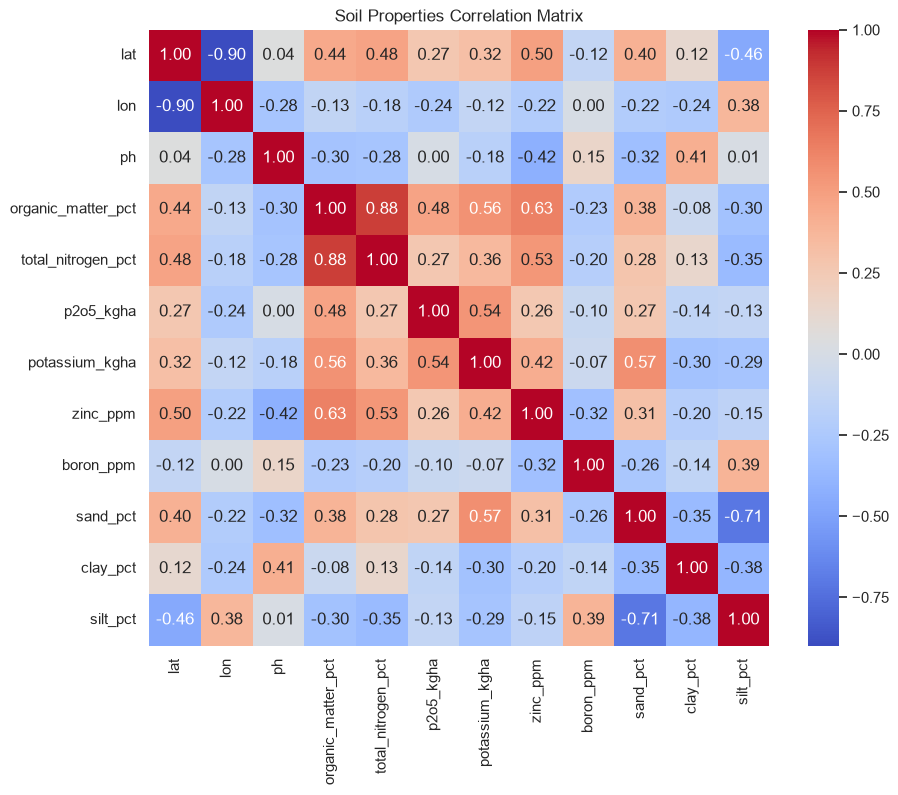

In [6]:
numeric_soil = soil_df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_soil.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Soil Properties Correlation Matrix")
plt.show()